# Part 1: Exploratory Data Analysis (EDA)
**Dataset:** IMDB Dataset of 50,000 Movie Reviews


# Part B – Q1.2: Exploratory Data Analysis (EDA)
**Dataset:** IMDB Dataset of 50,000 Movie Reviews  
**Task:** Binary Sentiment Classification — `positive` vs `negative`


In [ ]:
# ── Imports ───────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

import nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)

# Consistent plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print("Libraries loaded successfully.")


Libraries loaded successfully.


## 1. Dataset Overview

In [8]:
# ── Load dataset ──────────────────────────────────────────────────────────────
df = pd.read_csv('IMDB Dataset.csv')

# Encode sentiment as numeric label for later use
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

print("=" * 45)
print("         DATASET Overview")
print("=" * 45)
print(f"  Total reviews    : {len(df):,}")
print(f"  Columns          : {list(df.columns)}")
print(f"  Missing values   : {df.isnull().sum().sum()}")
print(f"  Duplicate rows   : {df.duplicated().sum()}")
print("=" * 45)
print()
print("Data Types:")
print(df.dtypes)
print()
print("First 3 rows:")
df.head(3)


         DATASET Overview
  Total reviews    : 50,000
  Columns          : ['review', 'sentiment', 'label']
  Missing values   : 0
  Duplicate rows   : 418

Data Types:
review       object
sentiment    object
label         int64
dtype: object

First 3 rows:


,review,sentiment,label
0,One of the other reviewers has mentioned that ...,positive,1
1,A wonderful little production. <br /><br />The...,positive,1
2,I thought this was a wonderful way to spend ti...,positive,1


## 2. Class Distribution

Sentiment Distribution:
  Positive : 25,000  (50.0%)
  Negative : 25,000  (50.0%)


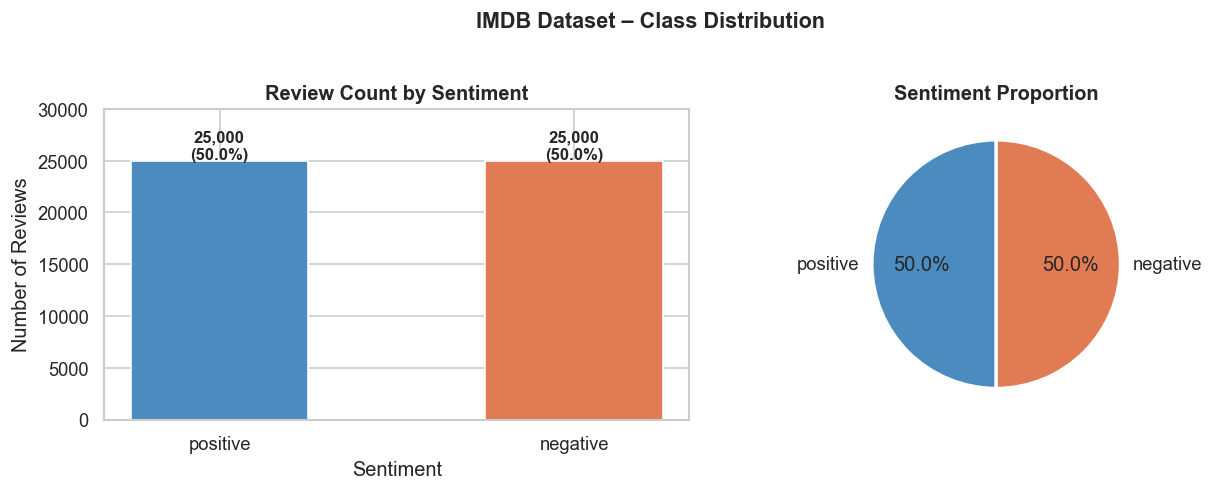

In [9]:
# ── Class distribution ────────────────────────────────────────────────────────
counts = df['sentiment'].value_counts()
pcts   = df['sentiment'].value_counts(normalize=True) * 100

print("Sentiment Distribution:")
print(f"  Positive : {counts['positive']:,}  ({pcts['positive']:.1f}%)")
print(f"  Negative : {counts['negative']:,}  ({pcts['negative']:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Bar chart
colors = ['#4C8BBF', '#E07B54']
bars = axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', width=0.5)
axes[0].set_title('Review Count by Sentiment', fontweight='bold')
axes[0].set_ylabel('Number of Reviews')
axes[0].set_xlabel('Sentiment')
for bar, pct in zip(bars, pcts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 200,
                 f'{bar.get_height():,}\n({pct:.1f}%)',
                 ha='center', fontsize=10, fontweight='bold')
axes[0].set_ylim(0, 30000)

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Sentiment Proportion', fontweight='bold')

plt.suptitle('IMDB Dataset – Class Distribution', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. Review Length Analysis

Review Length Statistics (Word Count):
             count   mean    std   min    25%    50%    75%     max
sentiment                                                          
negative   25000.0  229.5  164.9   4.0  128.0  174.0  278.0  1522.0
positive   25000.0  232.8  177.5  10.0  125.0  172.0  284.0  2470.0


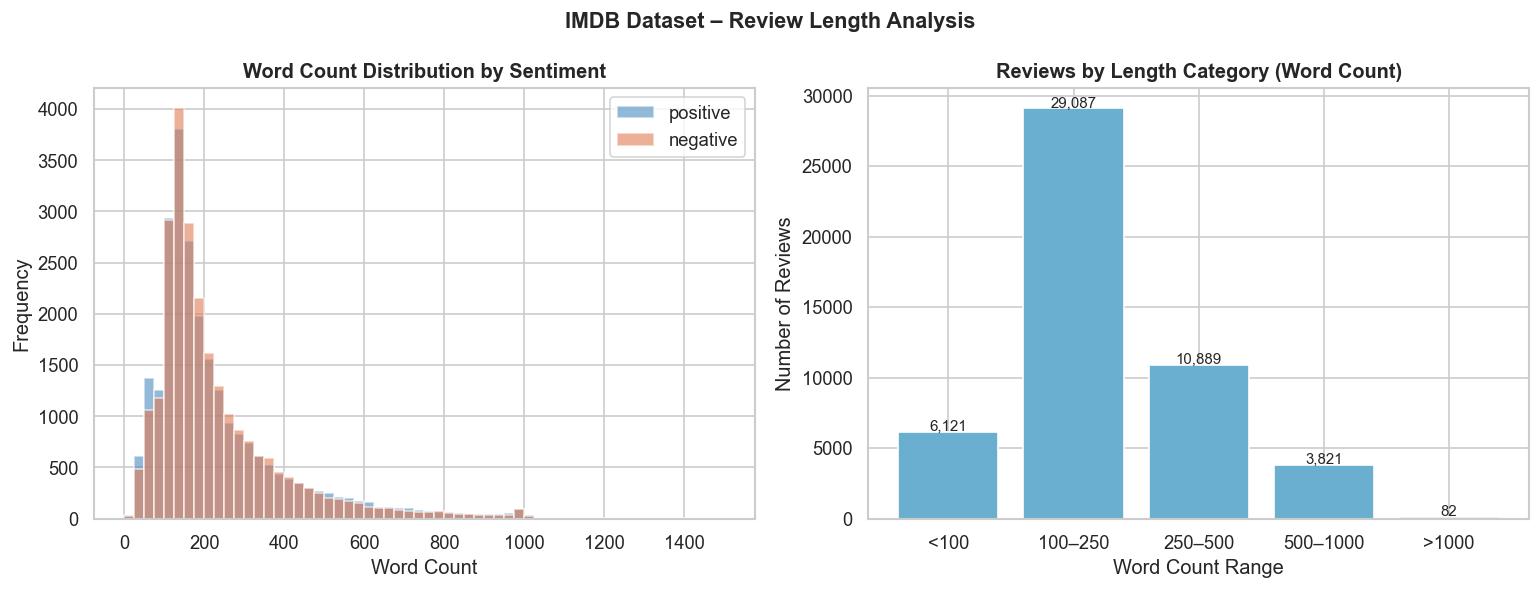

In [10]:
# ── Compute review lengths ────────────────────────────────────────────────────
df['word_count'] = df['review'].str.split().str.len()

print("Review Length Statistics (Word Count):")
print(df.groupby('sentiment')['word_count'].describe().round(1).to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 1. Word count histogram by sentiment
for label, color in zip(['positive', 'negative'], ['#4C8BBF', '#E07B54']):
    subset = df[df['sentiment'] == label]['word_count']
    axes[0].hist(subset, bins=60, alpha=0.6, color=color, label=label, range=(0, 1500))
axes[0].set_title('Word Count Distribution by Sentiment', fontweight='bold')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# 2. Review length buckets
bins   = [0, 100, 250, 500, 1000, df['word_count'].max()]
labels = ['<100', '100–250', '250–500', '500–1000', '>1000']
df['length_bucket'] = pd.cut(df['word_count'], bins=bins, labels=labels)
bucket_counts = df['length_bucket'].value_counts().sort_index()
axes[1].bar(bucket_counts.index, bucket_counts.values, color='#6AAFCF', edgecolor='white')
axes[1].set_title('Reviews by Length Category (Word Count)', fontweight='bold')
axes[1].set_xlabel('Word Count Range')
axes[1].set_ylabel('Number of Reviews')
for i, v in enumerate(bucket_counts.values):
    axes[1].text(i, v + 100, f'{v:,}', ha='center', fontsize=9)

plt.suptitle('IMDB Dataset – Review Length Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_review_length.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Vocabulary & Descriptive Statistics

Descriptive Statistics Summary:
           word_count  unique_words  lexical_richness
sentiment                                            
negative       229.46        139.44              0.66
positive       232.85        139.25              0.65


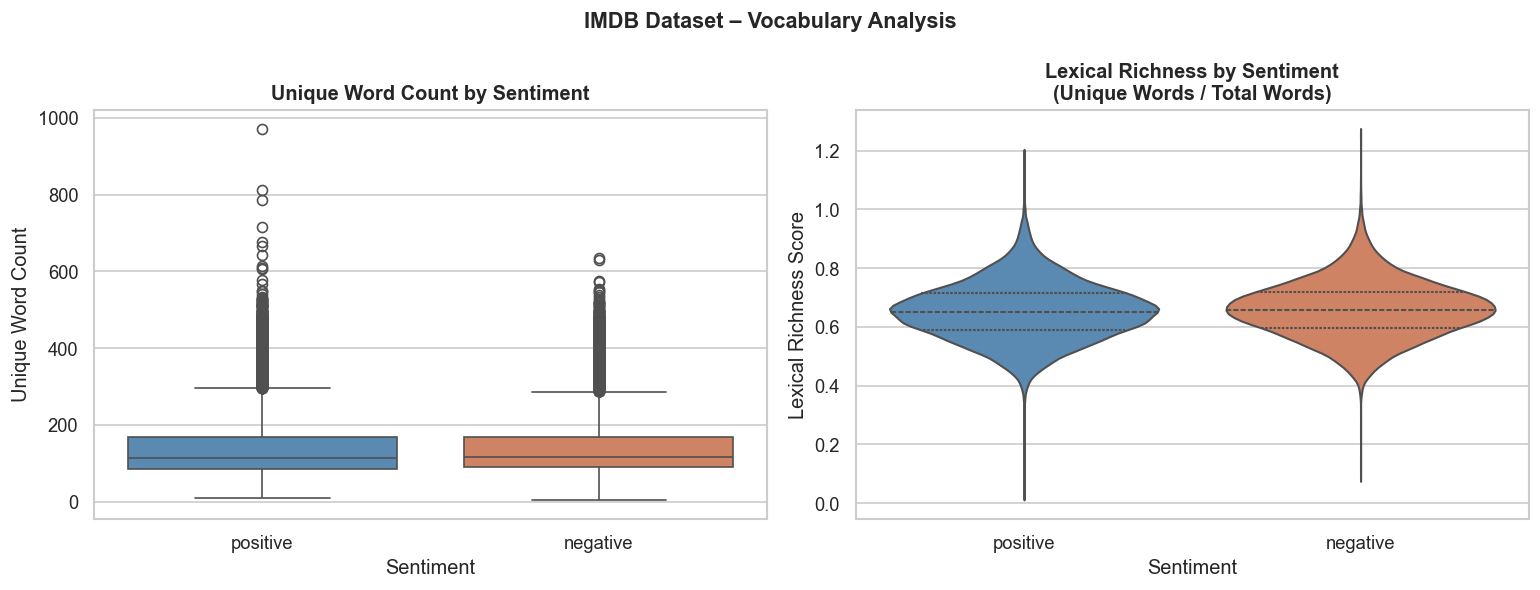

In [13]:
# ── Unique word count per review ──────────────────────────────────────────────
df['unique_words'] = df['review'].apply(
    lambda x: len(set(re.sub(r'[^a-zA-Z]', ' ', x).lower().split()))
)

# ── Lexical richness = unique words / total words ─────────────────────────────
df['lexical_richness'] = df['unique_words'] / df['word_count']

print("Descriptive Statistics Summary:")
stats = df.groupby('sentiment')[['word_count', 'unique_words', 'lexical_richness']].mean().round(2)
print(stats.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Unique words boxplot
sns.boxplot(data=df, x='sentiment', y='unique_words',
            palette={'positive': '#4C8BBF', 'negative': '#E07B54'}, ax=axes[0])
axes[0].set_title('Unique Word Count by Sentiment', fontweight='bold')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Unique Word Count')

# Lexical richness violin
sns.violinplot(data=df, x='sentiment', y='lexical_richness',
               palette={'positive': '#4C8BBF', 'negative': '#E07B54'},
               inner='quartile', ax=axes[1])
axes[1].set_title('Lexical Richness by Sentiment\n(Unique Words / Total Words)', fontweight='bold')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Lexical Richness Score')

plt.suptitle('IMDB Dataset – Vocabulary Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_vocabulary.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. EDA Summary & Key Findings

In [14]:
# ── Print consolidated EDA summary ───────────────────────────────────────────
print("=" * 55)
print("             EDA SUMMARY – IMDB DATASET")
print("=" * 55)
print(f"  Total reviews          : {len(df):,}")
print(f"  Positive reviews       : {(df['sentiment']=='positive').sum():,} (50%)")
print(f"  Negative reviews       : {(df['sentiment']=='negative').sum():,} (50%)")
print(f"  Missing values         : {df[['review','sentiment']].isnull().sum().sum()}")
print(f"  Duplicate rows         : {df.duplicated(subset=['review']).sum()}")
print()
print("  --- Review Length (Word Count) ---")
print(f"  Overall mean           : {df['word_count'].mean():.1f} words")
print(f"  Overall median         : {df['word_count'].median():.1f} words")
print(f"  Min / Max              : {df['word_count'].min()} / {df['word_count'].max()}")
print()
print("  --- Per Sentiment (Mean Word Count) ---")
for s in ['positive', 'negative']:
    m = df[df['sentiment']==s]['word_count'].mean()
    print(f"  {s.capitalize():<12}         : {m:.1f} words")
print()
print("  --- Vocabulary ---")
print(f"  Avg unique words/review: {df['unique_words'].mean():.1f}")
print(f"  Avg lexical richness   : {df['lexical_richness'].mean():.3f}")




             EDA SUMMARY – IMDB DATASET
  Total reviews          : 50,000
  Positive reviews       : 25,000 (50%)
  Negative reviews       : 25,000 (50%)
  Missing values         : 0
  Duplicate rows         : 418

  --- Review Length (Word Count) ---
  Overall mean           : 231.2 words
  Overall median         : 173.0 words
  Min / Max              : 4 / 2470

  --- Per Sentiment (Mean Word Count) ---
  Positive             : 232.8 words
  Negative             : 229.5 words

  --- Vocabulary ---
  Avg unique words/review: 139.3
  Avg lexical richness   : 0.657


# Part 2: Data Pre-Processing

## Data Pre-Processing

In [5]:
# ── Imports ───────────────────────────────────────────────────────────────────
import pandas as pd

In [6]:
# ── Load dataset ──────────────────────────────────────────────────────────────
df = pd.read_csv('IMDB Dataset.csv')

# Encode sentiment as numeric label for later use
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

print("=" * 45)
print("         DATASET Overview")
print("=" * 45)
print(f"  Total reviews    : {len(df):,}")
print(f"  Columns          : {list(df.columns)}")
print(f"  Missing values   : {df.isnull().sum().sum()}")
print(f"  Duplicate rows   : {df.duplicated().sum()}")
print("=" * 45)
print()
print("Data Types:")
print(df.dtypes)
print()
print("First 3 rows:")
df.head(3)


         DATASET Overview
  Total reviews    : 50,000
  Columns          : ['review', 'sentiment', 'label']
  Missing values   : 0
  Duplicate rows   : 418

Data Types:
review       object
sentiment    object
label         int64
dtype: object

First 3 rows:


,review,sentiment,label
0,One of the other reviewers has mentioned that ...,positive,1
1,A wonderful little production. <br /><br />The...,positive,1
2,I thought this was a wonderful way to spend ti...,positive,1


In [7]:
# ── Remove duplicate reviews ──────────────────────────────────────────────────
before = len(df)
df = df.drop_duplicates(subset=['review'])
after = len(df)

print(f"Rows before        : {before:,}")
print(f"Rows after         : {after:,}")
print(f"Duplicates removed : {before - after:,}")

# ── Overwrite original dataset with cleaned version ───────────────────────────
df.to_csv('IMDB Dataset.csv', index=False)
print(f"Saved {len(df):,} rows to 'IMDB Dataset.csv'")

Rows before        : 50,000
Rows after         : 49,582
Duplicates removed : 418
Saved 49,582 rows to 'IMDB Dataset.csv'


In [9]:
# ── Pre-Processed Dataset ───────────────────────────────────────────────────
print("Missing values:")
print(df.isnull().sum())
print()
print(f"Remaining duplicates : {df.duplicated(subset=['review']).sum()}")
print(f"Total rows remaining : {len(df):,}")

Missing values:
review       0
sentiment    0
label        0
dtype: int64

Remaining duplicates : 0
Total rows remaining : 49,582


# Part 3: SVM Model (LinearSVC)

# Part B – Sarvein: Supervised Text Classification (SVM Model)

**Dataset:** IMDB Dataset of 50K Movie Reviews  
**Task:** Binary Sentiment Classification — `positive` vs `negative`  
**Model:** Support Vector Machine (SVM) with TF-IDF features


In [ ]:
# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

# Text preprocessing
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# Model
from sklearn.svm import LinearSVC

# Evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# Download required NLTK data
nltk.download('stopwords', quiet=True)



True

In [ ]:
# ── Load Dataset ──────────────────────────────────────────────────────────────

df = pd.read_csv('IMDB Dataset.csv')

# Encode label: positive = 1, negative = 0
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

print(f"Dataset shape  : {df.shape}")
print(f"\nClass distribution:")
print(df['sentiment'].value_counts())
df.head(3)


Dataset shape  : (49582, 3)

Class distribution:
sentiment
positive    24884
negative    24698
Name: count, dtype: int64


,review,sentiment,label
0,One of the other reviewers has mentioned that ...,positive,1
1,A wonderful little production. <br /><br />The...,positive,1
2,I thought this was a wonderful way to spend ti...,positive,1


In [ ]:
# ── Text Preprocessing ────────────────────────────────────────────────────────
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def clean_text(text):
    # 1. Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)
    # 2. Remove non-alphabetic characters
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    # 3. Lowercase and tokenise
    tokens = text.lower().split()
    # 4 & 5. Remove stop words and stem
    tokens = [stemmer.stem(w) for w in tokens if w not in stop_words]
    return ' '.join(tokens)


df['clean_review'] = df['review'].apply(clean_text)
print(f"Done. Sample cleaned review:\n\n{df['clean_review'].iloc[0][:300]}")


Done. Sample cleaned review:

one review mention watch oz episod hook right exactli happen first thing struck oz brutal unflinch scene violenc set right word go trust show faint heart timid show pull punch regard drug sex violenc hardcor classic use word call oz nicknam given oswald maximum secur state penitentari focus mainli e


In [6]:
# ── Train/Test Split & TF-IDF Vectorisation ───────────────────────────────────
X = df['clean_review']
y = df['label']

# 80/20 stratified split to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# TF-IDF: convert text to numerical feature matrix
# max_features=40000 adjusted for cleaned dataset size
# ngram_range=(1,2) includes unigrams and bigrams
tfidf = TfidfVectorizer(max_features=40000, ngram_range=(1, 2), sublinear_tf=True)

X_train_tfidf = tfidf.fit_transform(X_train)   # fit on training data only
X_test_tfidf  = tfidf.transform(X_test)         # transform test data

print(f"Training samples : {X_train_tfidf.shape[0]}")
print(f"Test samples     : {X_test_tfidf.shape[0]}")
print(f"TF-IDF features  : {X_train_tfidf.shape[1]}")

Training samples : 39665
Test samples     : 9917
TF-IDF features  : 40000


In [7]:
# ── Build & Train SVM Model ───────────────────────────────────────────────────

svm_model = LinearSVC(C=1.0, max_iter=1000, random_state=42)

svm_model.fit(X_train_tfidf, y_train)

print("SVM model trained successfully.")


SVM model trained successfully.


In [8]:
# ── Model Evaluation ─────────────────────────────────────────────────────────
y_pred = svm_model.predict(X_test_tfidf)

# Compute evaluation metrics
acc       = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print("=" * 45)
print("         SVM MODEL EVALUATION RESULTS")
print("=" * 45)
print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print("=" * 45)
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))


         SVM MODEL EVALUATION RESULTS
  Accuracy  : 0.9002  (90.02%)
  Precision : 0.8977
  Recall    : 0.9042
  F1-Score  : 0.9009

Detailed Classification Report:
              precision    recall  f1-score   support

    Negative       0.90      0.90      0.90      4940
    Positive       0.90      0.90      0.90      4977

    accuracy                           0.90      9917
   macro avg       0.90      0.90      0.90      9917
weighted avg       0.90      0.90      0.90      9917



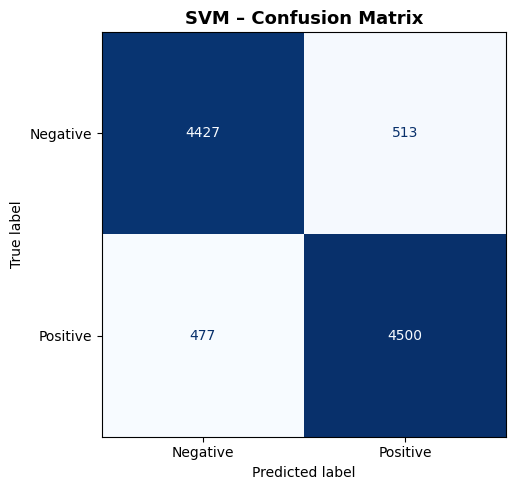

In [9]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('SVM – Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()



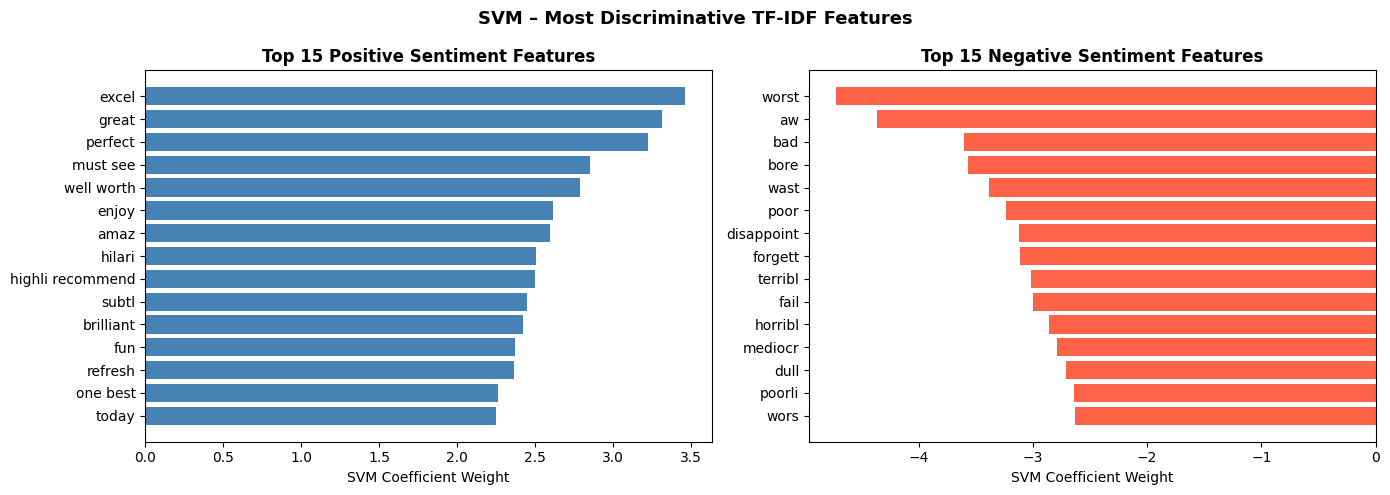

In [10]:
# ── Top Discriminative Features ───────────────────────────────────────────────
# Positive weights: associated with positive sentiment
# Negative weights: associated with negative sentiment

feature_names = tfidf.get_feature_names_out()
coef = svm_model.coef_[0]

top_n = 15
top_pos_idx = coef.argsort()[-top_n:][::-1]   # highest weights
top_neg_idx = coef.argsort()[:top_n]           # lowest (most negative) weights

top_pos_words   = [feature_names[i] for i in top_pos_idx]
top_pos_weights = [coef[i] for i in top_pos_idx]
top_neg_words   = [feature_names[i] for i in top_neg_idx]
top_neg_weights = [coef[i] for i in top_neg_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(top_pos_words[::-1], top_pos_weights[::-1], color='steelblue')
axes[0].set_title('Top 15 Positive Sentiment Features', fontweight='bold')
axes[0].set_xlabel('SVM Coefficient Weight')

axes[1].barh(top_neg_words[::-1], top_neg_weights[::-1], color='tomato')
axes[1].set_title('Top 15 Negative Sentiment Features', fontweight='bold')
axes[1].set_xlabel('SVM Coefficient Weight')

plt.suptitle('SVM – Most Discriminative TF-IDF Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()



---
# Part B – Q3: Hyperparameter Tuning (SVM)

GridSearchCV is used to systematically search over a defined parameter grid.  
5-fold cross-validation is applied on the training set for each combination.


In [11]:
# ── GridSearchCV ──────────────────────────────────────────────────────────────
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search over
param_grid = {
    'C'        : [0.01, 0.1, 1.0, 10.0],
    'loss'     : ['hinge', 'squared_hinge'],
    'max_iter' : [500, 1000]
}

# Initialise the base estimator
svm_base = LinearSVC(random_state=42)

# GridSearchCV with 5-fold cross-validation, scoring on F1 (macro)
# n_jobs=-1 uses all available CPU cores
grid_search = GridSearchCV(
    estimator  = svm_base,
    param_grid = param_grid,
    cv         = 5,
    scoring    = 'f1_macro',
    n_jobs     = -1,
    verbose    = 1
)

print("Running GridSearchCV over the following grid:")
print(param_grid)

grid_search.fit(X_train_tfidf, y_train)

print("\nGridSearchCV complete.")
print(f"Best Parameters : {grid_search.best_params_}")
print(f"Best CV F1 Score: {grid_search.best_score_:.4f}")


Running GridSearchCV over the following grid:
{'C': [0.01, 0.1, 1.0, 10.0], 'loss': ['hinge', 'squared_hinge'], 'max_iter': [500, 1000]}
Fitting 5 folds for each of 16 candidates, totalling 80 fits

GridSearchCV complete.
Best Parameters : {'C': 1.0, 'loss': 'hinge', 'max_iter': 500}
Best CV F1 Score: 0.8999


In [12]:
# ── Evaluate Best Tuned SVM on Test Set ───────────────────────────────────────
best_svm = grid_search.best_estimator_

y_pred_tuned = best_svm.predict(X_test_tfidf)

acc_t   = accuracy_score(y_test, y_pred_tuned)
prec_t  = precision_score(y_test, y_pred_tuned)
rec_t   = recall_score(y_test, y_pred_tuned)
f1_t    = f1_score(y_test, y_pred_tuned)

print("=" * 50)
print("     TUNED SVM MODEL EVALUATION RESULTS")
print("=" * 50)
print(f"  Accuracy  : {acc_t:.4f}  ({acc_t*100:.2f}%)")
print(f"  Precision : {prec_t:.4f}")
print(f"  Recall    : {rec_t:.4f}")
print(f"  F1-Score  : {f1_t:.4f}")
print("=" * 50)
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_tuned, target_names=['Negative', 'Positive']))


     TUNED SVM MODEL EVALUATION RESULTS
  Accuracy  : 0.9017  (90.17%)
  Precision : 0.8950
  Recall    : 0.9110
  F1-Score  : 0.9029

Detailed Classification Report:
              precision    recall  f1-score   support

    Negative       0.91      0.89      0.90      4940
    Positive       0.89      0.91      0.90      4977

    accuracy                           0.90      9917
   macro avg       0.90      0.90      0.90      9917
weighted avg       0.90      0.90      0.90      9917



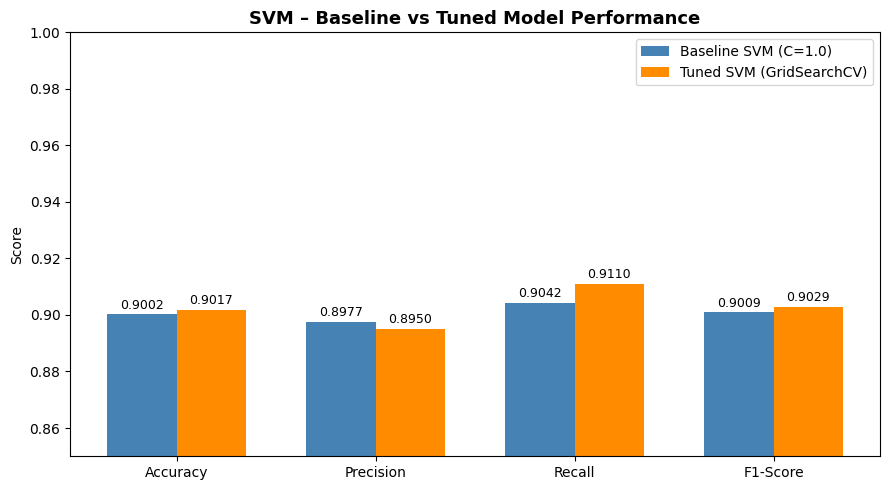

In [13]:
# ── Before vs After Tuning Comparison ────────────────────────────────────────
metrics       = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
baseline_vals = [acc,   precision, recall, f1]
tuned_vals    = [acc_t, prec_t,    rec_t,  f1_t]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, baseline_vals, width, label='Baseline SVM (C=1.0)',  color='steelblue')
bars2 = ax.bar(x + width/2, tuned_vals,    width, label='Tuned SVM (GridSearchCV)', color='darkorange')

ax.set_ylim(0.85, 1.0)
ax.set_ylabel('Score')
ax.set_title('SVM – Baseline vs Tuned Model Performance', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

# Annotate bars with exact values
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()



# Part 4: Logistic Regression Model

# Part B - Rama: Supervised Text Classification (Logistic Regression Model with TF-IDF Vectorization)

**Dataset:** IMDB Dataset of 50K Movie Reviews  
**Task:** Binary Sentiment Classification — `positive` vs `negative`  
**Model:** Logistic Regression Model with TF-IDF Vectorization

In [3]:
# -----------------------------------------------------------
# Import libraries
# -----------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
)
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings("ignore")

print("All libraries are imported successfully.")

All libraries are imported successfully.


In [4]:
# -----------------------------------------------------------
# Load the IMDB dataset
# -----------------------------------------------------------


df = pd.read_csv("IMDB Dataset.csv")

# Minor dataset inspection
print(f"Dataset shape: {df.shape}")
print(f"\nColumn names: {df.columns.tolist()}")
print(f"\nLabel distribution:\n{df['label'].value_counts()}")
print(f"\nSample rows:")
df.head()

Dataset shape: (49582, 3)

Column names: ['review', 'sentiment', 'label']

Label distribution:
label
1    24884
0    24698
Name: count, dtype: int64

Sample rows:


,review,sentiment,label
0,One of the other reviewers has mentioned that ...,positive,1
1,A wonderful little production. <br /><br />The...,positive,1
2,I thought this was a wonderful way to spend ti...,positive,1
3,Basically there's a family where a little boy ...,negative,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1


In [5]:
# -----------------------------------------------------------
# Train / Test Split — 80% training / 20% testing
# -----------------------------------------------------------

X = df["review"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print(f"Training set size : {len(X_train)}")
print(f"Testing set size  : {len(X_test)}")
print(f"\nTraining label distribution:\n{y_train.value_counts()}")
print(f"\nTesting label distribution:\n{y_test.value_counts()}")

Training set size : 39665
Testing set size  : 9917

Training label distribution:
label
1    19907
0    19758
Name: count, dtype: int64

Testing label distribution:
label
1    4977
0    4940
Name: count, dtype: int64


In [6]:
# -----------------------------------------------------------
# TF-IDF Vectorization — Convert text to numerical features
# -----------------------------------------------------------


tfidf_vectorizer = TfidfVectorizer(
    max_features=50000,       
    ngram_range=(1, 2),       
    sublinear_tf=True,        
    min_df=2,                 
    max_df=0.95,              
    strip_accents="unicode",  
    dtype=np.float32,         
)

print("TF-IDF Vectorizer configured:")
print(f"  max_features  : 50,000")
print(f"  ngram_range   : (1, 2) — unigrams + bigrams")
print(f"  sublinear_tf  : True (log scaling)")
print(f"  min_df        : 2")
print(f"  max_df        : 0.95")

TF-IDF Vectorizer configured:
  max_features  : 50,000
  ngram_range   : (1, 2) — unigrams + bigrams
  sublinear_tf  : True (log scaling)
  min_df        : 2
  max_df        : 0.95


In [7]:
# -----------------------------------------------------------
# Fit TF-IDF and Transform the data
# -----------------------------------------------------------

print("Fitting TF-IDF vectorizer on training data")
start_time = time.time()

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf  = tfidf_vectorizer.transform(X_test)

tfidf_time = time.time() - start_time

print(f"\nTF-IDF vectorization complete in {tfidf_time:.2f}s")
print(f"  Training matrix shape : {X_train_tfidf.shape}")
print(f"  Testing matrix shape  : {X_test_tfidf.shape}")
print(f"  Vocabulary size       : {len(tfidf_vectorizer.vocabulary_)}")
print(f"  Matrix density        : {X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1]):.4%}")

# Sample feature names (top unigrams and bigrams)
feature_names = tfidf_vectorizer.get_feature_names_out()
print(f"\n  Sample unigrams : {[f for f in feature_names[:10]]}")
print(f"  Sample bigrams  : {[f for f in feature_names if ' ' in f][:10]}")

Fitting TF-IDF vectorizer on training data

TF-IDF vectorization complete in 32.81s
  Training matrix shape : (39665, 50000)
  Testing matrix shape  : (9917, 50000)
  Vocabulary size       : 50000
  Matrix density        : 0.4789%

  Sample unigrams : ['00', '000', '000 000', '000 to', '007', '01', '02', '10', '10 000', '10 10']
  Sample bigrams  : ['000 000', '000 to', '10 000', '10 10', '10 15', '10 and', '10 because', '10 bethany', '10 br', '10 but']


In [8]:
# -----------------------------------------------------------
# Building the Logistic Regression model
# -----------------------------------------------------------


lr_model = LogisticRegression(
    C=1.0,                        
    solver="lbfgs",               
    max_iter=1000,                
    class_weight="balanced",      
    random_state=42,              
    n_jobs=-1,                    
)

print("Logistic Regression model configured:")
print(f"  C (regularisation) : 1.0")
print(f"  Solver             : lbfgs")
print(f"  Max iterations     : 1000")
print(f"  Class weight       : balanced")

Logistic Regression model configured:
  C (regularisation) : 1.0
  Solver             : lbfgs
  Max iterations     : 1000
  Class weight       : balanced


In [9]:
# -----------------------------------------------------------
# Train the model
# -----------------------------------------------------------

print("=" * 60)
print("Training Logistic Regression on IMDB dataset")
print("=" * 60)

start_time = time.time()
lr_model.fit(X_train_tfidf, y_train)
train_time = time.time() - start_time

print(f"\nTraining complete!")
print(f"  Training time     : {train_time:.2f}s")
print(f"  Number of features: {X_train_tfidf.shape[1]}")
print(f"  Number of classes : {len(lr_model.classes_)}")
print(f"  Coefficients shape: {lr_model.coef_.shape}")
print(f"  Intercept         : {lr_model.intercept_[0]:.4f}")

Training Logistic Regression on IMDB dataset

Training complete!
  Training time     : 5.85s
  Number of features: 50000
  Number of classes : 2
  Coefficients shape: (1, 50000)
  Intercept         : 0.1599


In [37]:
# -----------------------------------------------------------
# Display  most influential features - Top 20 positive and negative indicators
# -----------------------------------------------------------

feature_names = tfidf_vectorizer.get_feature_names_out()
coefficients  = lr_model.coef_[0]

top_positive_idx = np.argsort(coefficients)[-20:][::-1]
top_negative_idx = np.argsort(coefficients)[:20]

print("=" * 60)
print("Top 20 Most Influential Features")
print("=" * 60)

print("\n--- Strongest POSITIVE sentiment indicators ---")
for i, idx in enumerate(top_positive_idx, 1):
    print(f"  {i:2d}. {feature_names[idx]:<25} (coeff: {coefficients[idx]:+.4f})")

print("\n--- Strongest NEGATIVE sentiment indicators ---")
for i, idx in enumerate(top_negative_idx, 1):
    print(f"  {i:2d}. {feature_names[idx]:<25} (coeff: {coefficients[idx]:+.4f})")

Top 20 Most Influential Features

--- Strongest POSITIVE sentiment indicators ---
   1. great                     (coeff: +8.3888)
   2. excellent                 (coeff: +6.4646)
   3. perfect                   (coeff: +5.2569)
   4. wonderful                 (coeff: +4.8300)
   5. amazing                   (coeff: +4.6968)
   6. best                      (coeff: +4.4545)
   7. the best                  (coeff: +4.2021)
   8. loved                     (coeff: +4.0904)
   9. brilliant                 (coeff: +4.0436)
  10. fun                       (coeff: +3.9488)
  11. today                     (coeff: +3.9190)
  12. love                      (coeff: +3.8892)
  13. enjoyed                   (coeff: +3.5751)
  14. superb                    (coeff: +3.5482)
  15. hilarious                 (coeff: +3.4122)
  16. enjoyable                 (coeff: +3.3129)
  17. favorite                  (coeff: +3.2995)
  18. well                      (coeff: +3.2952)
  19. especially                (coe

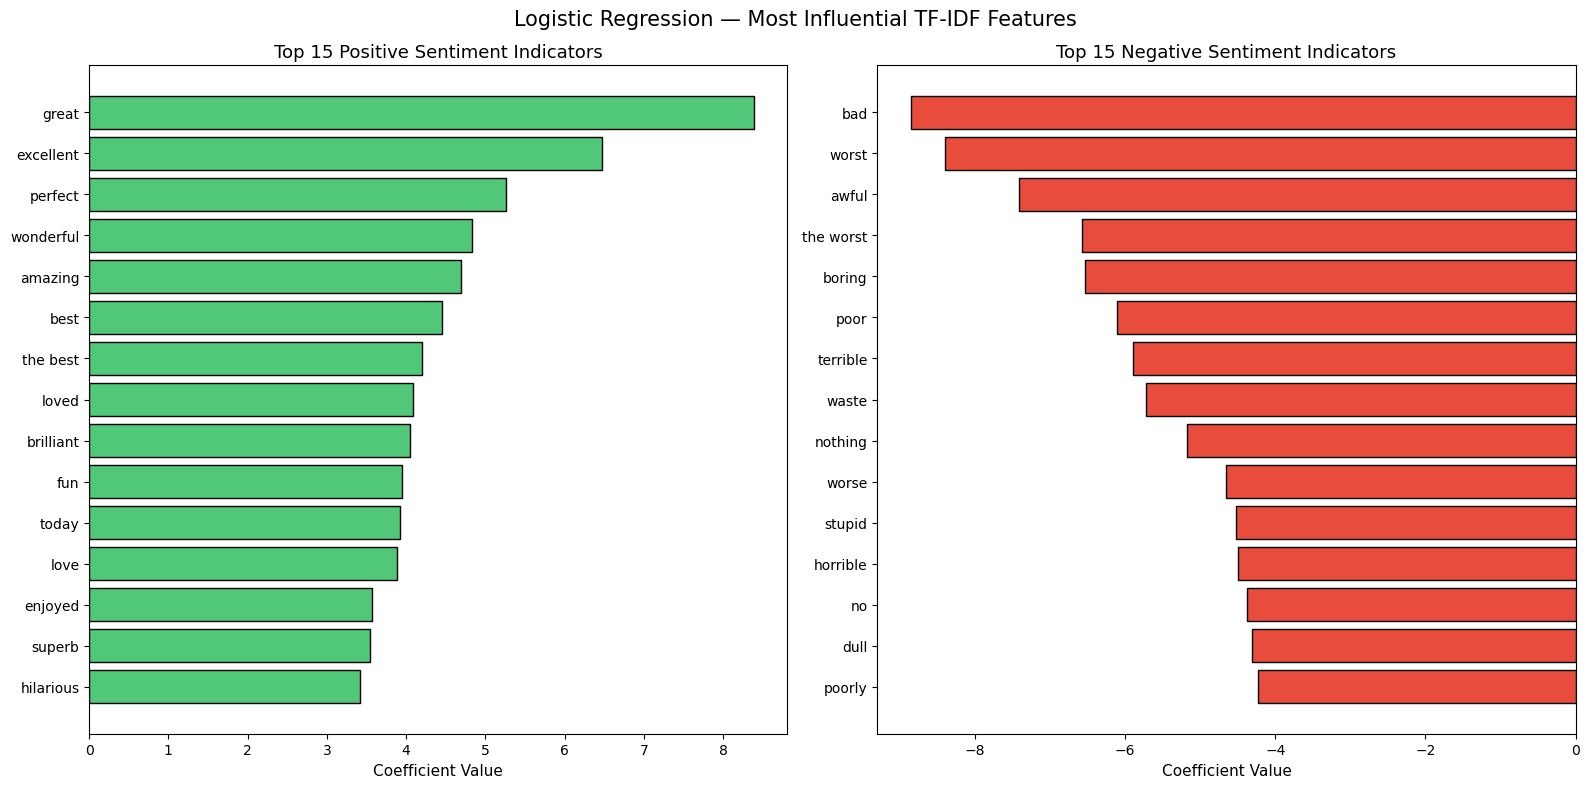

In [11]:
# -----------------------------------------------------------
# Top features Visualisation
# -----------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Top 15 positive features
top_pos_15 = top_positive_idx[:15]
axes[0].barh(
    [feature_names[i] for i in top_pos_15][::-1],
    [coefficients[i] for i in top_pos_15][::-1],
    color="#50C878",
    edgecolor="black",
)
axes[0].set_title("Top 15 Positive Sentiment Indicators", fontsize=13)
axes[0].set_xlabel("Coefficient Value", fontsize=11)

# Top 15 negative features
top_neg_15 = top_negative_idx[:15]
axes[1].barh(
    [feature_names[i] for i in top_neg_15][::-1],
    [coefficients[i] for i in top_neg_15][::-1],
    color="#E74C3C",
    edgecolor="black",
)
axes[1].set_title("Top 15 Negative Sentiment Indicators", fontsize=13)
axes[1].set_xlabel("Coefficient Value", fontsize=11)

plt.suptitle("Logistic Regression — Most Influential TF-IDF Features", fontsize=15)
plt.tight_layout()
plt.show()

In [34]:
# ============================================================
# Model Evaluation and Results Presentation
# ============================================================

# -----------------------------------------------------------
# Generate predictions
# -----------------------------------------------------------

print("=" * 60)
print("Logistic Regression Model Evaluation on Test Set")
print("=" * 60)

# Predicted class labels
y_pred = lr_model.predict(X_test_tfidf)

# Predicted probabilities (for ROC-AUC)
y_pred_proba = lr_model.predict_proba(X_test_tfidf)[:, 1]

# Calculate all metrics
eval_accuracy  = accuracy_score(y_test, y_pred)
eval_precision = precision_score(y_test, y_pred, average="binary")
eval_recall    = recall_score(y_test, y_pred, average="binary")
eval_f1        = f1_score(y_test, y_pred, average="binary")
eval_roc_auc   = roc_auc_score(y_test, y_pred_proba)

print(f"\nEvaluation Results:")
print(f"  Accuracy  : {eval_accuracy:.4f} ({eval_accuracy*100:.2f}%)")
print(f"  Precision : {eval_precision:.4f}")
print(f"  Recall    : {eval_recall:.4f}")
print(f"  F1-Score  : {eval_f1:.4f}")
print(f"  ROC-AUC   : {eval_roc_auc:.4f}")

print(f"\nTotal training time: {train_time:.2f}s")
print(f"TF-IDF vectorization time: {tfidf_time:.2f}s")

Logistic Regression Model Evaluation on Test Set

Evaluation Results:
  Accuracy  : 0.9061 (90.61%)
  Precision : 0.8953
  Recall    : 0.9206
  F1-Score  : 0.9078
  ROC-AUC   : 0.9680

Total training time: 5.85s
TF-IDF vectorization time: 32.81s


In [35]:
# -----------------------------------------------------------
# Classification Report
# -----------------------------------------------------------

print("=" * 60)
print("Classification Report")
print("=" * 60)
print(classification_report(
    y_test,
    y_pred,
    target_names=["Negative (0)", "Positive (1)"],
    digits=4,
))

Classification Report
              precision    recall  f1-score   support

Negative (0)     0.9177    0.8915    0.9044      4940
Positive (1)     0.8953    0.9206    0.9078      4977

    accuracy                         0.9061      9917
   macro avg     0.9065    0.9061    0.9061      9917
weighted avg     0.9064    0.9061    0.9061      9917



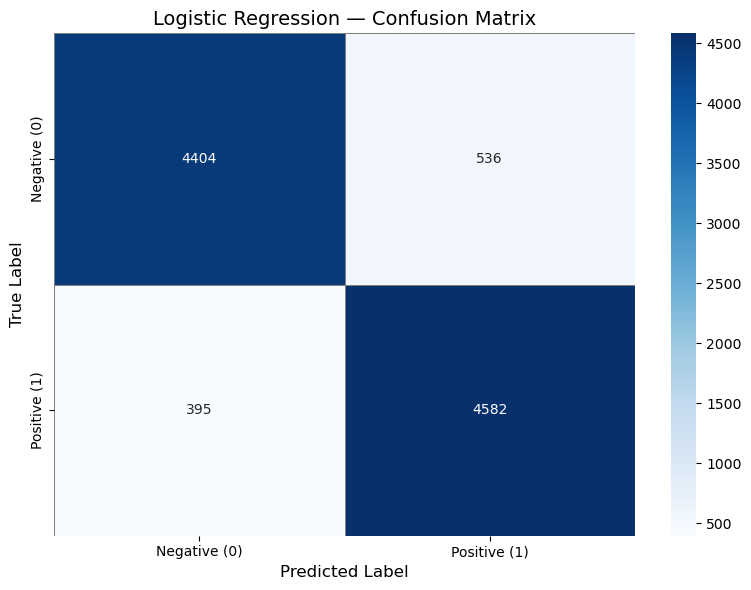


Confusion Matrix Breakdown:
  True Negatives  (TN): 4404
  False Positives (FP): 536
  False Negatives (FN): 395
  True Positives  (TP): 4582


In [14]:
# -----------------------------------------------------------
# Visualisation - Confusion Matrix 
# -----------------------------------------------------------

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative (0)", "Positive (1)"],
    yticklabels=["Negative (0)", "Positive (1)"],
    linewidths=0.5,
    linecolor="gray",
)
plt.title("Logistic Regression — Confusion Matrix", fontsize=14)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.tight_layout()
plt.show()


tn, fp, fn, tp = cm.ravel()
print(f"\nConfusion Matrix Breakdown:")
print(f"  True Negatives  (TN): {tn}")
print(f"  False Positives (FP): {fp}")
print(f"  False Negatives (FN): {fn}")
print(f"  True Positives  (TP): {tp}")

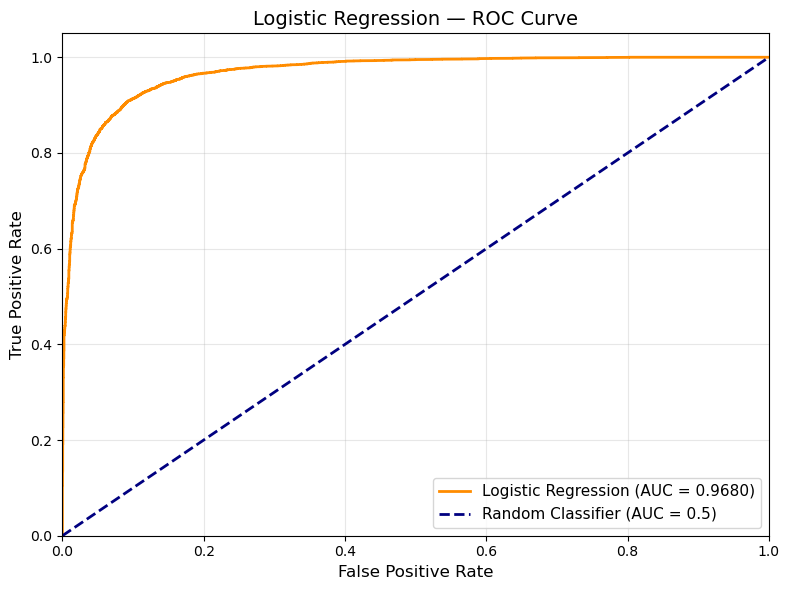

ROC-AUC Score: 0.9680


In [32]:
# -----------------------------------------------------------
# Visualisation - ROC Curve
# -----------------------------------------------------------

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2,
         label=f"Logistic Regression (AUC = {eval_roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--",
         label="Random Classifier (AUC = 0.5)")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("Logistic Regression — ROC Curve", fontsize=14)
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"ROC-AUC Score: {eval_roc_auc:.4f}")

In [17]:
# -----------------------------------------------------------
# Sample Predictions
# -----------------------------------------------------------

label_map = {0: "Negative", 1: "Positive"}

print("=" * 60)
print("Sample Predictions from the Test Set")
print("=" * 60)

np.random.seed(42)
sample_indices = np.random.choice(len(X_test), size=10, replace=False)

for i, idx in enumerate(sample_indices, 1):
    review_text = X_test.iloc[idx]
    true_label  = y_test.iloc[idx]
    pred_label  = y_pred[idx]
    pred_prob   = y_pred_proba[idx]
    status      = "✓" if true_label == pred_label else "✗"

    print(f"\n--- Sample {i} [{status}] ---")
    print(f"  Review   : {review_text[:150]}...")
    print(f"  True     : {label_map[true_label]}")
    print(f"  Predicted: {label_map[pred_label]} (confidence: {pred_prob:.4f})")

Sample Predictions from the Test Set

--- Sample 1 [✓] ---
  Review   : I'm sure this was one of those "WOAH!" attractions in 1982 when Epcot opened, but now it's just silly. The film's message is cliché. The Circle-Vision...
  True     : Negative
  Predicted: Negative (confidence: 0.0720)

--- Sample 2 [✓] ---
  Review   : I liked this movies. Its a another Yash raj film which you know will look good on screen, all character are always nice or very nice with one exceptio...
  True     : Positive
  Predicted: Positive (confidence: 0.9025)

--- Sample 3 [✓] ---
  Review   : The entire thing is very beautiful to look at..the European location shooting was a good idea. The lead actors are attractive. The score is servicable...
  True     : Negative
  Predicted: Negative (confidence: 0.0587)

--- Sample 4 [✓] ---
  Review   : "Children of wax" also shown as "Killing grounds" is an interesting mixture of genres. Some might think the purity of the genre can be only for good b...
  True     :

---

# Part B – Q3: Hyperparameter Tuning (Logistic Regression)


In [18]:
# -----------------------------------------------------------
# Import extra libraries
# -----------------------------------------------------------

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer

from scipy.stats import uniform, randint


import warnings
warnings.filterwarnings("ignore")

print("Extra libraries for Hyperparameter Tuning imported successfully.")


Extra libraries for Hyperparameter Tuning imported successfully.


In [19]:
# -----------------------------------------------------------
# Summary table of hyperparameters
# -----------------------------------------------------------

hyperparam_table = pd.DataFrame({
    "Component": [
        "TF-IDF", "TF-IDF", "TF-IDF", "TF-IDF",
        "Logistic Regression", "Logistic Regression", "Logistic Regression",
    ],
    "Hyperparameter": [
        "max_features", "ngram_range", "sublinear_tf", "min_df",
        "C", "solver", "class_weight",
    ],
    "Baseline Value": [
        "50000", "(1,2)", "True", "2",
        "1.0", "lbfgs", "balanced",
    ],
    "Search Range": [
        "[30000, 50000, 70000, 100000]",
        "[(1,1), (1,2), (1,3)]",
        "[True, False]",
        "[1, 2, 3, 5]",
        "[0.01, 0.1, 0.5, 1.0, 5.0, 10.0]",
        "[lbfgs, liblinear, saga]",
        "[None, balanced]",
    ],
    "Impact": [
        "Vocabulary size & dimensionality",
        "Phrase capture (negation handling)",
        "Term frequency scaling",
        "Rare term filtering",
        "Regularisation (bias-variance trade-off)",
        "Optimisation convergence",
        "Class importance weighting",
    ],
})

print("=" * 70)
print("Hyperparameter Summary Table")
print("=" * 70)
print(hyperparam_table.to_string(index=False))
print("=" * 70)

total_combinations = 4 * 3 * 2 * 4 * 6 * 3 * 2
print(f"\nTotal possible combinations: {total_combinations}")

Hyperparameter Summary Table
          Component Hyperparameter Baseline Value                     Search Range                                   Impact
             TF-IDF   max_features          50000    [30000, 50000, 70000, 100000]         Vocabulary size & dimensionality
             TF-IDF    ngram_range          (1,2)            [(1,1), (1,2), (1,3)]       Phrase capture (negation handling)
             TF-IDF   sublinear_tf           True                    [True, False]                   Term frequency scaling
             TF-IDF         min_df              2                     [1, 2, 3, 5]                      Rare term filtering
Logistic Regression              C            1.0 [0.01, 0.1, 0.5, 1.0, 5.0, 10.0] Regularisation (bias-variance trade-off)
Logistic Regression         solver          lbfgs         [lbfgs, liblinear, saga]                 Optimisation convergence
Logistic Regression   class_weight       balanced                 [None, balanced]               Class 

In [20]:

# Hyperparameter Tuning using RandomizedSearchCV

# -----------------------------------------------------------
# Build the sklearn Pipeline - combining TF-IDF and Logistic Regression
# -----------------------------------------------------------


pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        strip_accents="unicode",
        dtype=np.float32,
        max_df=0.95,
    )),
    ("lr", LogisticRegression(
        max_iter=1000,
        random_state=42,
        n_jobs=-1,
    )),
])

print("Pipeline created:")
print(pipeline)

Pipeline created:
Pipeline(steps=[('tfidf',
                 TfidfVectorizer(dtype=<class 'numpy.float32'>, max_df=0.95,
                                 strip_accents='unicode')),
                ('lr',
                 LogisticRegression(max_iter=1000, n_jobs=-1,
                                    random_state=42))])


In [21]:
# -----------------------------------------------------------
# Define the hyperparameter search space
# -----------------------------------------------------------

param_distributions = {
    # TF-IDF hyperparameters
    "tfidf__max_features":  [30000, 50000, 70000],  
    "tfidf__ngram_range":   [(1, 1), (1, 2), (1, 3)],
    "tfidf__sublinear_tf":  [True, False],
    "tfidf__min_df":        [1, 2, 3, 5],

    # Logistic Regression hyperparameters
    "lr__C":                [0.01, 0.1, 0.5, 1.0, 5.0, 10.0],
    "lr__solver":           ["lbfgs", "liblinear", "saga"],
    "lr__class_weight":     [None, "balanced"],
}

total_combinations = 3 * 3 * 2 * 4 * 6 * 3 * 2
print("Hyperparameter Search Space for RandomizedSearchCV:")
print("=" * 60)
for param, values in param_distributions.items():
    print(f"  {param:<30}: {values}")
print(f"\nTotal possible combinations: {total_combinations}")

Hyperparameter Search Space for RandomizedSearchCV:
  tfidf__max_features           : [30000, 50000, 70000]
  tfidf__ngram_range            : [(1, 1), (1, 2), (1, 3)]
  tfidf__sublinear_tf           : [True, False]
  tfidf__min_df                 : [1, 2, 3, 5]
  lr__C                         : [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]
  lr__solver                    : ['lbfgs', 'liblinear', 'saga']
  lr__class_weight              : [None, 'balanced']

Total possible combinations: 2592


In [22]:
# -----------------------------------------------------------
# Configure and Run RandomizedSearchCV
# -----------------------------------------------------------

N_ITER = 20  
N_FOLDS = 5  

cv_strategy = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

f1_scorer = make_scorer(f1_score, average="binary")

random_search = RandomizedSearchCV(
    estimator=pipeline,                      
    param_distributions=param_distributions, 
    n_iter=N_ITER,                           
    scoring=f1_scorer,                       
    cv=cv_strategy,                          
    verbose=2,                               
    random_state=42,                         
    refit=True,                              
    n_jobs=1,                                
    return_train_score=True,                 
)

print("=" * 70)
print(f"RandomizedSearchCV — {N_ITER} iterations × {N_FOLDS} folds")
print("=" * 70)
print(f"Scoring metric : F1-score")
print(f"CV strategy    : {N_FOLDS}-fold Stratified Cross-Validation")
print(f"Total fits     : {N_ITER * N_FOLDS} ({N_ITER} combinations × {N_FOLDS} folds)")
print(f"Random state   : 42")
print(f"n_jobs         : 1 (sequential)")
print()

start_time = time.time()
random_search.fit(X_train, y_train)
search_time = time.time() - start_time

print("\n" + "=" * 70)
print("RandomizedSearchCV complete!")
print(f"Total search time: {search_time:.1f}s ({search_time/60:.1f} minutes)")
print("=" * 70)

RandomizedSearchCV — 20 iterations × 5 folds
Scoring metric : F1-score
CV strategy    : 5-fold Stratified Cross-Validation
Total fits     : 100 (20 combinations × 5 folds)
Random state   : 42
n_jobs         : 1 (sequential)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END lr__C=0.1, lr__class_weight=balanced, lr__solver=saga, tfidf__max_features=70000, tfidf__min_df=5, tfidf__ngram_range=(1, 2), tfidf__sublinear_tf=True; total time=  30.8s
[CV] END lr__C=0.1, lr__class_weight=balanced, lr__solver=saga, tfidf__max_features=70000, tfidf__min_df=5, tfidf__ngram_range=(1, 2), tfidf__sublinear_tf=True; total time=  28.7s
[CV] END lr__C=0.1, lr__class_weight=balanced, lr__solver=saga, tfidf__max_features=70000, tfidf__min_df=5, tfidf__ngram_range=(1, 2), tfidf__sublinear_tf=True; total time=  33.5s
[CV] END lr__C=0.1, lr__class_weight=balanced, lr__solver=saga, tfidf__max_features=70000, tfidf__min_df=5, tfidf__ngram_range=(1, 2), tfidf__sublinear_tf=True; total time= 

In [23]:
# -----------------------------------------------------------
# Display best hyperparameters
# -----------------------------------------------------------

print("=" * 70)
print("Best Hyperparameters by RandomizedSearchCV")
print("=" * 70)
print(f"\nBest Cross-Validated F1-Score: {random_search.best_score_:.4f}")
print(f"\nBest Hyperparameters:")
for param, value in random_search.best_params_.items():
    display_name = param.replace("tfidf__", "TF-IDF: ").replace("lr__", "LR: ")
    print(f"  {display_name:<30}: {value}")

Best Hyperparameters by RandomizedSearchCV

Best Cross-Validated F1-Score: 0.9113

Best Hyperparameters:
  TF-IDF: sublinear_tf          : False
  TF-IDF: ngram_range           : (1, 2)
  TF-IDF: min_df                : 2
  TF-IDF: max_features          : 70000
  LR: solver                    : lbfgs
  LR: class_weight              : balanced
  LR: C                         : 10.0


In [24]:
# -----------------------------------------------------------
# Display all trial results in a ranked table
# -----------------------------------------------------------

results_df = pd.DataFrame(random_search.cv_results_)


trials_table = results_df[[
    "rank_test_score",
    "mean_test_score",
    "std_test_score",
    "mean_train_score",
    "param_tfidf__max_features",
    "param_tfidf__ngram_range",
    "param_tfidf__sublinear_tf",
    "param_tfidf__min_df",
    "param_lr__C",
    "param_lr__solver",
    "param_lr__class_weight",
    "mean_fit_time",
]].copy()

trials_table.columns = [
    "Rank", "Mean F1 (Test)", "Std F1", "Mean F1 (Train)",
    "max_features", "ngram_range", "sublinear_tf", "min_df",
    "C", "solver", "class_weight", "Fit Time (s)",
]


trials_table = trials_table.sort_values("Rank").reset_index(drop=True)


trials_table["Mean F1 (Test)"]  = trials_table["Mean F1 (Test)"].apply(lambda x: f"{x:.4f}")
trials_table["Std F1"]          = trials_table["Std F1"].apply(lambda x: f"{x:.4f}")
trials_table["Mean F1 (Train)"] = trials_table["Mean F1 (Train)"].apply(lambda x: f"{x:.4f}")
trials_table["Fit Time (s)"]    = trials_table["Fit Time (s)"].apply(lambda x: f"{x:.1f}")

print("=" * 70)
print(f"RandomizedSearchCV — All {N_ITER} Trial Results (sorted by rank)")
print("=" * 70)
print(trials_table.to_string(index=False))
print("=" * 70)

RandomizedSearchCV — All 20 Trial Results (sorted by rank)
 Rank Mean F1 (Test) Std F1 Mean F1 (Train)  max_features ngram_range  sublinear_tf  min_df     C    solver class_weight Fit Time (s)
    1         0.9113 0.0020          0.9927         70000      (1, 2)         False       2 10.00     lbfgs     balanced         28.0
    2         0.9096 0.0019          0.9843         50000      (1, 3)         False       5  5.00      saga     balanced         59.9
    3         0.9090 0.0016          0.9928         30000      (1, 2)          True       5 10.00      saga         None         29.2
    4         0.9078 0.0019          0.9896         30000      (1, 2)         False       2 10.00     lbfgs         None         29.3
    5         0.9076 0.0022          0.9899         30000      (1, 2)         False       3 10.00     lbfgs     balanced         30.5
    6         0.9036 0.0013          0.9449         50000      (1, 3)         False       1  1.00      saga     balanced         62.9
   

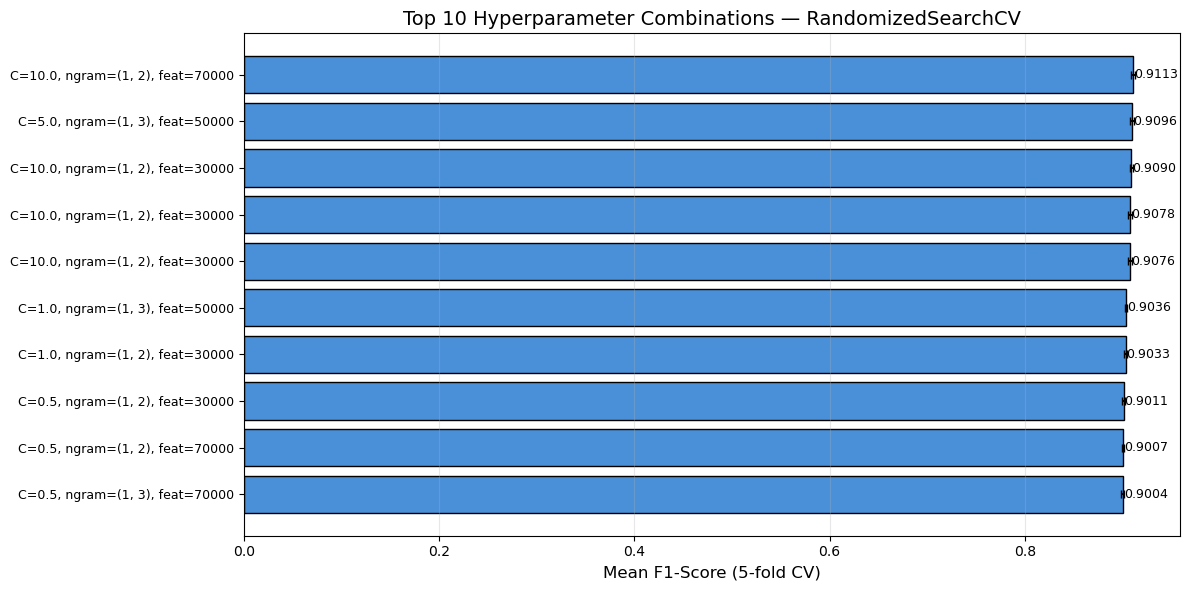

In [25]:
# -----------------------------------------------------------
# Visualisation - Top 10 Hyperparameter Combinations
# -----------------------------------------------------------

top_10 = results_df.nsmallest(10, "rank_test_score")

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.barh(
    range(10),
    top_10["mean_test_score"].values[::-1],
    xerr=top_10["std_test_score"].values[::-1],
    color="#4A90D9",
    edgecolor="black",
    capsize=3,
)

labels = []
for _, row in top_10.iterrows():
    labels.append(
        f"C={row['param_lr__C']}, "
        f"ngram={row['param_tfidf__ngram_range']}, "
        f"feat={row['param_tfidf__max_features']}"
    )

ax.set_yticks(range(10))
ax.set_yticklabels(labels[::-1], fontsize=9)
ax.set_xlabel("Mean F1-Score (5-fold CV)", fontsize=12)
ax.set_title("Top 10 Hyperparameter Combinations — RandomizedSearchCV", fontsize=14)
ax.grid(axis="x", alpha=0.3)


for i, bar in enumerate(bars):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f"{bar.get_width():.4f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

In [26]:
# -----------------------------------------------------------
# Comparing Baseline vs Best Hyperparameters
# -----------------------------------------------------------

baseline_params = {
    "tfidf__max_features":  50000,
    "tfidf__ngram_range":   (1, 2),
    "tfidf__sublinear_tf":  True,
    "tfidf__min_df":        2,
    "lr__C":                1.0,
    "lr__solver":           "lbfgs",
    "lr__class_weight":     "balanced",
}

best_params = random_search.best_params_

comparison_data = []
for param in baseline_params:
    baseline_val = baseline_params[param]
    best_val = best_params.get(param, "N/A")
    changed = "Yes" if str(baseline_val) != str(best_val) else "No"
    display_name = param.replace("tfidf__", "TF-IDF: ").replace("lr__", "LR: ")
    comparison_data.append({
        "Hyperparameter": display_name,
        "Baseline": str(baseline_val),
        "Best (Tuned)": str(best_val),
        "Changed": changed,
    })

comparison_df = pd.DataFrame(comparison_data)

print("=" * 70)
print("Baseline (Q2) vs Best Hyperparameters (Q3) Comparison")
print("=" * 70)
print(comparison_df.to_string(index=False))
print("=" * 70)

Baseline (Q2) vs Best Hyperparameters (Q3) Comparison
      Hyperparameter Baseline Best (Tuned) Changed
TF-IDF: max_features    50000        70000     Yes
 TF-IDF: ngram_range   (1, 2)       (1, 2)      No
TF-IDF: sublinear_tf     True        False     Yes
      TF-IDF: min_df        2            2      No
               LR: C      1.0         10.0     Yes
          LR: solver    lbfgs        lbfgs      No
    LR: class_weight balanced     balanced      No


In [36]:
# -----------------------------------------------------------
# Logistic Regression Model Results (After Hyperparameter Tuning)
# -----------------------------------------------------------


print("=" * 70)
print("Tuned Model Evaluation on Test Set")
print("=" * 70)

best_pipeline = random_search.best_estimator_


y_pred_tuned       = best_pipeline.predict(X_test)
y_pred_proba_tuned = best_pipeline.predict_proba(X_test)[:, 1]


tuned_accuracy  = accuracy_score(y_test, y_pred_tuned)
tuned_precision = precision_score(y_test, y_pred_tuned, average="binary")
tuned_recall    = recall_score(y_test, y_pred_tuned, average="binary")
tuned_f1        = f1_score(y_test, y_pred_tuned, average="binary")
tuned_roc_auc   = roc_auc_score(y_test, y_pred_proba_tuned)

print(f"\nResults:")
print(f"  Accuracy  : {tuned_accuracy:.4f} ({tuned_accuracy*100:.2f}%)")
print(f"  Precision : {tuned_precision:.4f}")
print(f"  Recall    : {tuned_recall:.4f}")
print(f"  F1-Score  : {tuned_f1:.4f}")
print(f"  ROC-AUC   : {tuned_roc_auc:.4f}")

#  Classification report
print(f"\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_tuned,
    target_names=["Negative (0)", "Positive (1)"],
    digits=4,
))

Tuned Model Evaluation on Test Set

Results:
  Accuracy  : 0.9123 (91.23%)
  Precision : 0.9067
  Recall    : 0.9198
  F1-Score  : 0.9132
  ROC-AUC   : 0.9714

Classification Report:
              precision    recall  f1-score   support

Negative (0)     0.9180    0.9047    0.9113      4940
Positive (1)     0.9067    0.9198    0.9132      4977

    accuracy                         0.9123      9917
   macro avg     0.9124    0.9122    0.9123      9917
weighted avg     0.9124    0.9123    0.9123      9917



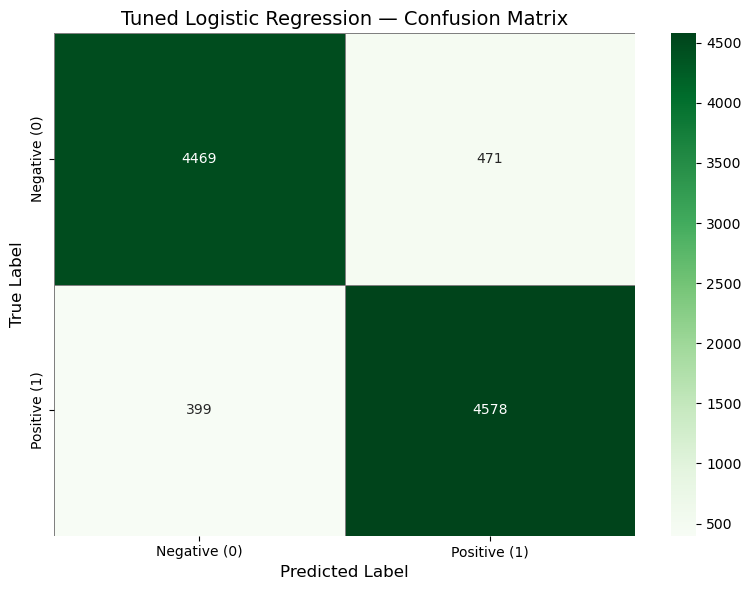

Confusion Matrix Breakdown:
  True Negatives  (TN): 4469
  False Positives (FP): 471
  False Negatives (FN): 399
  True Positives  (TP): 4578


In [28]:
# -----------------------------------------------------------
# Visualization - Confusion matrix for the tuned model
# -----------------------------------------------------------

cm_tuned = confusion_matrix(y_test, y_pred_tuned)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_tuned,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Negative (0)", "Positive (1)"],
    yticklabels=["Negative (0)", "Positive (1)"],
    linewidths=0.5,
    linecolor="gray",
)
plt.title("Tuned Logistic Regression — Confusion Matrix", fontsize=14)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_tuned.ravel()
print(f"Confusion Matrix Breakdown:")
print(f"  True Negatives  (TN): {tn}")
print(f"  False Positives (FP): {fp}")
print(f"  False Negatives (FN): {fn}")
print(f"  True Positives  (TP): {tp}")

In [29]:
# -----------------------------------------------------------
# Baseline vs Tuned Performance Comparison 
# -----------------------------------------------------------

baseline_results = {
    "Accuracy":  eval_accuracy,
    "Precision": eval_precision,
    "Recall":    eval_recall,
    "F1-Score":  eval_f1,
    "ROC-AUC":   eval_roc_auc,
}

tuned_results = {
    "Accuracy":  tuned_accuracy,
    "Precision": tuned_precision,
    "Recall":    tuned_recall,
    "F1-Score":  tuned_f1,
    "ROC-AUC":   tuned_roc_auc,
}

# Comparison table
perf_df = pd.DataFrame({
    "Metric": list(baseline_results.keys()),
    "Baseline": [f"{v:.4f}" for v in baseline_results.values()],
    "Tuned": [f"{v:.4f}" for v in tuned_results.values()],
    "Improvement": [
        f"{tuned_results[m] - baseline_results[m]:+.4f}" for m in baseline_results
    ],
})

print("=" * 70)
print("Model Performance Comparison: Baseline (Q2) vs Tuned (Q3)")
print("=" * 70)
print(perf_df.to_string(index=False))
print("=" * 70)

f1_diff = tuned_results["F1-Score"] - baseline_results["F1-Score"]
if f1_diff > 0:
    print(f"\n✓ Hyperparameter tuning IMPROVED F1-score by {f1_diff:.4f}")
elif f1_diff == 0:
    print(f"\n— Hyperparameter tuning produced the SAME F1-score")
else:
    print(f"\n✗ Hyperparameter tuning DECREASED F1-score by {abs(f1_diff):.4f}")
    print("  The baseline configuration may already be near-optimal.")


Model Performance Comparison: Baseline (Q2) vs Tuned (Q3)
   Metric Baseline  Tuned Improvement
 Accuracy   0.9061 0.9123     +0.0062
Precision   0.8953 0.9067     +0.0114
   Recall   0.9206 0.9198     -0.0008
 F1-Score   0.9078 0.9132     +0.0054
  ROC-AUC   0.9680 0.9714     +0.0034

✓ Hyperparameter tuning IMPROVED F1-score by 0.0054


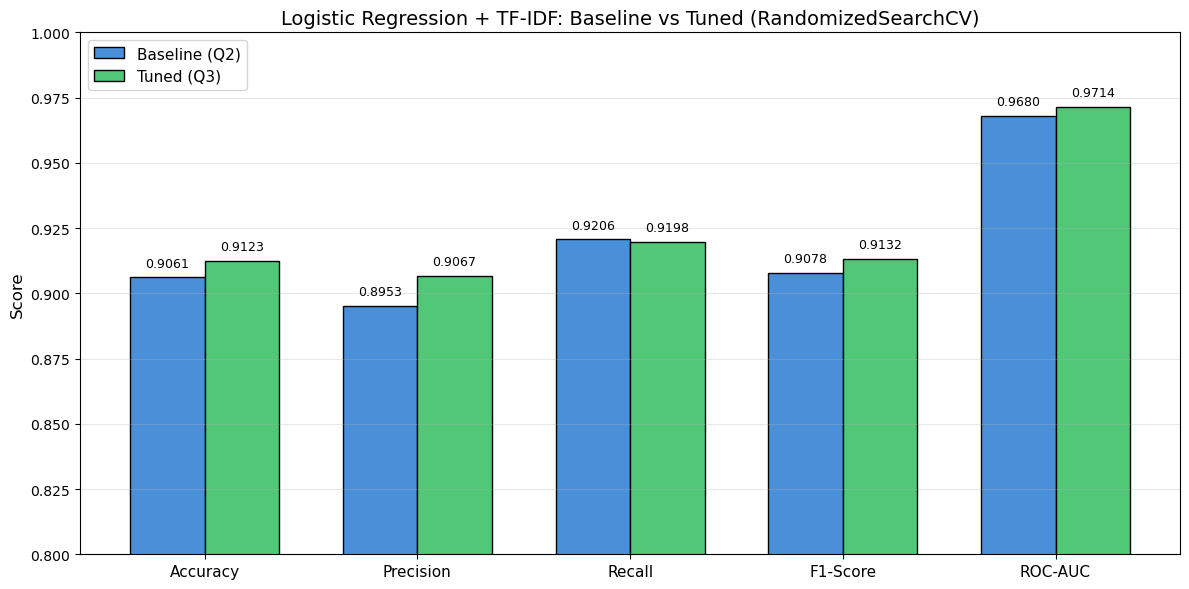

In [30]:
# -----------------------------------------------------------
# Visualization - Bar chart (Baseline vs Tuned performance)
# -----------------------------------------------------------

baseline_results = {
    "Accuracy":  eval_accuracy,
    "Precision": eval_precision,
    "Recall":    eval_recall,
    "F1-Score":  eval_f1,
    "ROC-AUC":   eval_roc_auc,
}

tuned_results = {
    "Accuracy":  tuned_accuracy,
    "Precision": tuned_precision,
    "Recall":    tuned_recall,
    "F1-Score":  tuned_f1,
    "ROC-AUC":   tuned_roc_auc,
}

metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
baseline_vals = [baseline_results[m] for m in metrics]
tuned_vals    = [tuned_results[m] for m in metrics]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, baseline_vals, width, label="Baseline (Q2)",
               color="#4A90D9", edgecolor="black")
bars2 = ax.bar(x + width/2, tuned_vals, width, label="Tuned (Q3)",
               color="#50C878", edgecolor="black")

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.003,
            f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.003,
            f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=9)

ax.set_ylabel("Score", fontsize=12)
ax.set_title("Logistic Regression + TF-IDF: Baseline vs Tuned (RandomizedSearchCV)",
             fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim(0.80, 1.0)  
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [31]:
# -----------------------------------------------------------
# Final Summary
# -----------------------------------------------------------

print("=" * 70)
print("HYPERPARAMETER TUNING SUMMARY (Q3)")
print("=" * 70)
print(f"""
Method Used      : RandomizedSearchCV
Iterations       : {N_ITER} random combinations
Cross-Validation : {N_FOLDS}-fold Stratified CV
Scoring Metric   : F1-score
Total Search Time: {search_time:.1f}s ({search_time/60:.1f} minutes)

Best CV F1-Score : {random_search.best_score_:.4f}

Best Hyperparameters Found:""")
for param, value in random_search.best_params_.items():
    display_name = param.replace("tfidf__", "TF-IDF: ").replace("lr__", "LR: ")
    print(f"  {display_name:<30}: {value}")

print(f"""
Test Set Performance (Tuned Model):
  Accuracy  : {tuned_accuracy:.4f}
  Precision : {tuned_precision:.4f}
  Recall    : {tuned_recall:.4f}
  F1-Score  : {tuned_f1:.4f}
  ROC-AUC   : {tuned_roc_auc:.4f}
""")
print("=" * 70)

HYPERPARAMETER TUNING SUMMARY (Q3)

Method Used      : RandomizedSearchCV
Iterations       : 20 random combinations
Cross-Validation : 5-fold Stratified CV
Scoring Metric   : F1-score
Total Search Time: 4921.1s (82.0 minutes)

Best CV F1-Score : 0.9113

Best Hyperparameters Found:
  TF-IDF: sublinear_tf          : False
  TF-IDF: ngram_range           : (1, 2)
  TF-IDF: min_df                : 2
  TF-IDF: max_features          : 70000
  LR: solver                    : lbfgs
  LR: class_weight              : balanced
  LR: C                         : 10.0

Test Set Performance (Tuned Model):
  Accuracy  : 0.9123
  Precision : 0.9067
  Recall    : 0.9198
  F1-Score  : 0.9132
  ROC-AUC   : 0.9714



# Part 5: Random Forest Model

In [2]:
# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

# Text preprocessing
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# Model
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# Download required NLTK data
nltk.download('stopwords', quiet=True)


True

In [3]:
# ── Load Dataset ──────────────────────────────────────────────────────────────
# Ensure 'IMDB Dataset.csv' is in the same directory as this notebook
df = pd.read_csv('IMDB Dataset.csv')

# Encode label: positive = 1, negative = 0
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

print(f"Dataset shape  : {df.shape}")
print(f"\nClass distribution:")
print(df['sentiment'].value_counts())
df.head(3)


Dataset shape  : (49582, 3)

Class distribution:
sentiment
positive    24884
negative    24698
Name: count, dtype: int64


,review,sentiment,label
0,One of the other reviewers has mentioned that ...,positive,1
1,A wonderful little production. <br /><br />The...,positive,1
2,I thought this was a wonderful way to spend ti...,positive,1


In [4]:
# ── Text Preprocessing ────────────────────────────────────────────────────────
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def clean_text(text):
    # 1. Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)
    # 2. Remove non-alphabetic characters
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    # 3. Lowercase and tokenise
    tokens = text.lower().split()
    # 4 & 5. Remove stop words and stem
    tokens = [stemmer.stem(w) for w in tokens if w not in stop_words]
    return ' '.join(tokens)

# Apply cleaning to all reviews (this may take ~1-2 minutes)
print("Cleaning reviews... please wait.")
df['clean_review'] = df['review'].apply(clean_text)
print(f"Done. Sample cleaned review:\n\n{df['clean_review'].iloc[0][:300]}")


Cleaning reviews... please wait.
Done. Sample cleaned review:

one review mention watch oz episod hook right exactli happen first thing struck oz brutal unflinch scene violenc set right word go trust show faint heart timid show pull punch regard drug sex violenc hardcor classic use word call oz nicknam given oswald maximum secur state penitentari focus mainli e


In [5]:
# ── Train/Test Split & TF-IDF Vectorisation ───────────────────────────────────
X = df['clean_review']
y = df['label']

# 80/20 stratified split to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# TF-IDF: convert text to numerical feature matrix
# max_features=40000 adjusted for cleaned dataset size
# ngram_range=(1,2) includes unigrams and bigrams
# Note: max_features is reduced for Random Forest to manage training time
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), sublinear_tf=True)

X_train_tfidf = tfidf.fit_transform(X_train)   # fit on training data only
X_test_tfidf  = tfidf.transform(X_test)         # transform test data

print(f"Training samples : {X_train_tfidf.shape[0]}")
print(f"Test samples     : {X_test_tfidf.shape[0]}")
print(f"TF-IDF features  : {X_train_tfidf.shape[1]}")


Training samples : 39665
Test samples     : 9917
TF-IDF features  : 10000


In [6]:
# ── Build & Train Random Forest Model ────────────────────────────────────────
# RandomForestClassifier is an ensemble method that builds multiple decision
# trees and combines their predictions through majority voting.
# n_estimators: number of trees in the forest
# n_jobs=-1: uses all available CPU cores for faster training
# random_state=42: ensures reproducibility

rf_model = RandomForestClassifier(
    n_estimators = 100,
    random_state = 42,
    n_jobs       = -1
)

print("Training Random Forest model... please wait.")
rf_model.fit(X_train_tfidf, y_train)
print("Random Forest model trained successfully.")


Training Random Forest model... please wait.
Random Forest model trained successfully.


In [7]:
# ── Model Evaluation ──────────────────────────────────────────────────────────
y_pred = rf_model.predict(X_test_tfidf)

# Compute evaluation metrics
acc       = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print("=" * 50)
print("     RANDOM FOREST MODEL EVALUATION RESULTS")
print("=" * 50)
print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print("=" * 50)
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))


     RANDOM FOREST MODEL EVALUATION RESULTS
  Accuracy  : 0.8528  (85.28%)
  Precision : 0.8501
  Recall    : 0.8579
  F1-Score  : 0.8540

Detailed Classification Report:
              precision    recall  f1-score   support

    Negative       0.86      0.85      0.85      4940
    Positive       0.85      0.86      0.85      4977

    accuracy                           0.85      9917
   macro avg       0.85      0.85      0.85      9917
weighted avg       0.85      0.85      0.85      9917



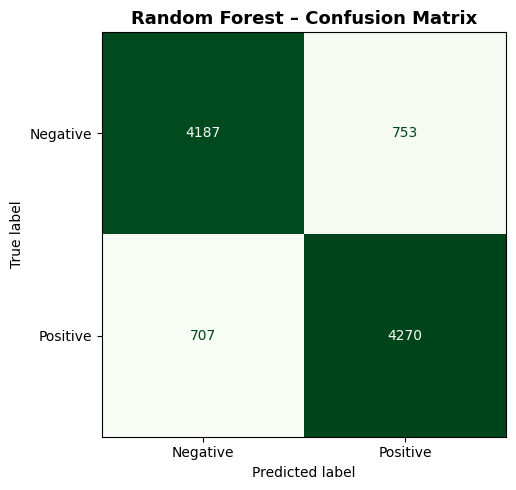

In [8]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
disp.plot(ax=ax, colorbar=False, cmap='Greens')
ax.set_title('Random Forest – Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


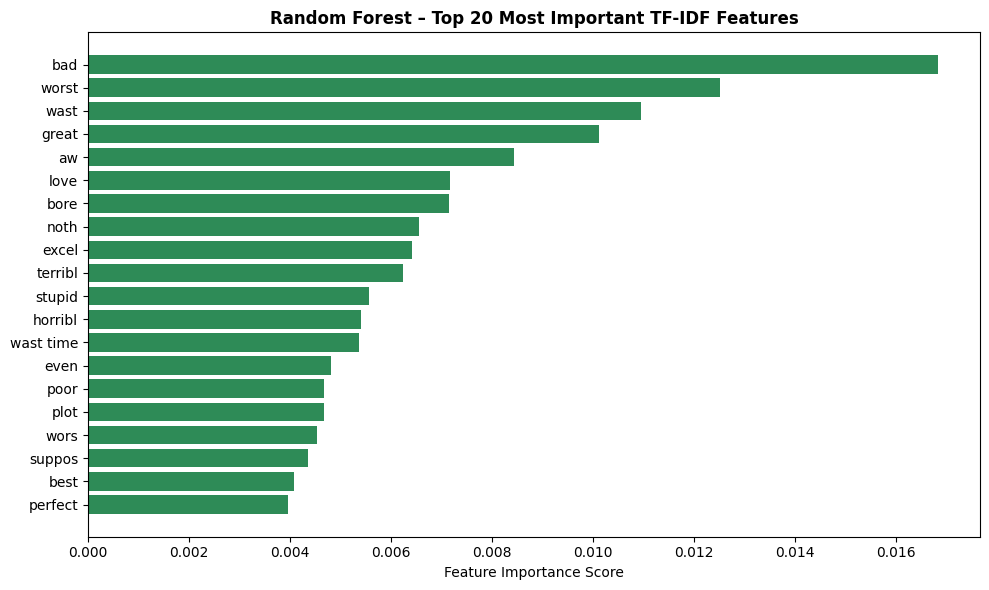

In [9]:
# ── Top Feature Importances ───────────────────────────────────────────────────
# Random Forest provides a feature_importances_ attribute which reflects
# how much each TF-IDF feature contributed to reducing impurity across all trees.
# Higher importance = more useful for classification.

feature_names  = tfidf.get_feature_names_out()
importances    = rf_model.feature_importances_

top_n      = 20
top_idx    = importances.argsort()[-top_n:][::-1]
top_words  = [feature_names[i] for i in top_idx]
top_scores = [importances[i] for i in top_idx]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_words[::-1], top_scores[::-1], color='seagreen')
ax.set_title('Random Forest – Top 20 Most Important TF-IDF Features', fontweight='bold', fontsize=12)
ax.set_xlabel('Feature Importance Score')
plt.tight_layout()
plt.show()


---
# Part B – Q3: Hyperparameter Tuning (Random Forest)

GridSearchCV is used to systematically search over a defined parameter grid.  
5-fold cross-validation is applied on the training set for each combination.


In [10]:
# ── GridSearchCV ──────────────────────────────────────────────────────────────
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search over
param_grid = {
    'n_estimators'    : [100, 200],
    'max_depth'       : [None, 20, 50],
    'min_samples_split': [2, 5]
}

# Initialise base estimator
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

# GridSearchCV with 5-fold cross-validation, scoring on F1 macro
grid_search = GridSearchCV(
    estimator  = rf_base,
    param_grid = param_grid,
    cv         = 5,
    scoring    = 'f1_macro',
    n_jobs     = -1,
    verbose    = 1
)

print("Running GridSearchCV over the following grid:")
print(param_grid)
print("\nThis may take several minutes...\n")

grid_search.fit(X_train_tfidf, y_train)

print("\nGridSearchCV complete.")
print(f"Best Parameters : {grid_search.best_params_}")
print(f"Best CV F1 Score: {grid_search.best_score_:.4f}")


Running GridSearchCV over the following grid:
{'n_estimators': [100, 200], 'max_depth': [None, 20, 50], 'min_samples_split': [2, 5]}

This may take several minutes...

Fitting 5 folds for each of 12 candidates, totalling 60 fits

GridSearchCV complete.
Best Parameters : {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
Best CV F1 Score: 0.8571


In [11]:
# ── Evaluate Best Tuned Random Forest on Test Set ─────────────────────────────
best_rf = grid_search.best_estimator_

y_pred_tuned = best_rf.predict(X_test_tfidf)

acc_t   = accuracy_score(y_test, y_pred_tuned)
prec_t  = precision_score(y_test, y_pred_tuned)
rec_t   = recall_score(y_test, y_pred_tuned)
f1_t    = f1_score(y_test, y_pred_tuned)

print("=" * 55)
print("     TUNED RANDOM FOREST MODEL EVALUATION RESULTS")
print("=" * 55)
print(f"  Accuracy  : {acc_t:.4f}  ({acc_t*100:.2f}%)")
print(f"  Precision : {prec_t:.4f}")
print(f"  Recall    : {rec_t:.4f}")
print(f"  F1-Score  : {f1_t:.4f}")
print("=" * 55)
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_tuned, target_names=['Negative', 'Positive']))


     TUNED RANDOM FOREST MODEL EVALUATION RESULTS
  Accuracy  : 0.8588  (85.88%)
  Precision : 0.8519
  Recall    : 0.8700
  F1-Score  : 0.8608

Detailed Classification Report:
              precision    recall  f1-score   support

    Negative       0.87      0.85      0.86      4940
    Positive       0.85      0.87      0.86      4977

    accuracy                           0.86      9917
   macro avg       0.86      0.86      0.86      9917
weighted avg       0.86      0.86      0.86      9917



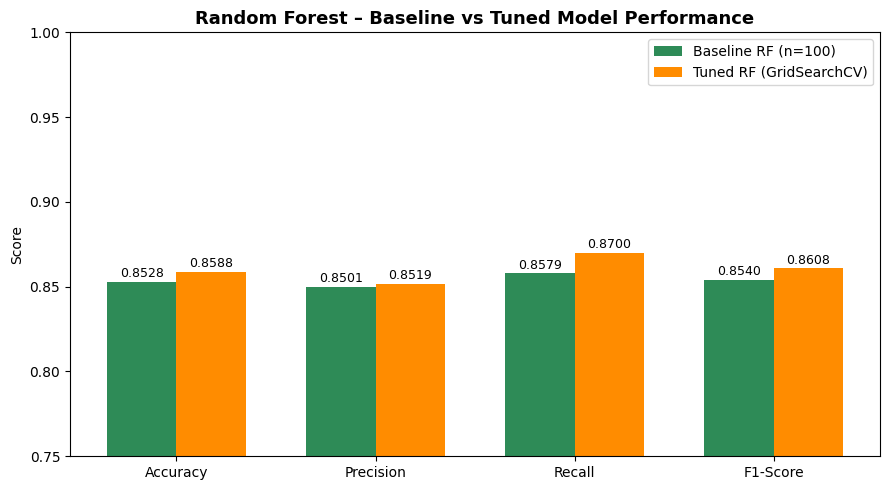

In [12]:
# ── Before vs After Tuning Comparison ────────────────────────────────────────
metrics       = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
baseline_vals = [acc,   precision, recall, f1]
tuned_vals    = [acc_t, prec_t,    rec_t,  f1_t]

x     = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, baseline_vals, width, label='Baseline RF (n=100)', color='seagreen')
bars2 = ax.bar(x + width/2, tuned_vals,    width, label='Tuned RF (GridSearchCV)', color='darkorange')

ax.set_ylim(0.75, 1.0)
ax.set_ylabel('Score')
ax.set_title('Random Forest – Baseline vs Tuned Model Performance', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

# Annotate bars with exact values
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


# Part 6: LSTM Model

In [ ]:
# ============================================
# IMPORT REQUIRED LIBRARIES
# ============================================

import numpy as np
import pandas as pd
# basic data handling

from sklearn.model_selection import train_test_split, RandomizedSearchCV
# data splitting and hyperparameter tuning

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# model evaluation

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
# text processing (convert text to numerical form)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
# model building (LSTM neural network)

from tensorflow.keras.callbacks import EarlyStopping
# training control

from scikeras.wrappers import KerasClassifier
# connect model with sklearn tuning


In [ ]:
# ============================================
# LOAD DATASET
# ============================================

df = pd.read_csv("C:/Users/irfan/Downloads/IMDB Dataset.csv")
# load dataset

df = df[["review", "label"]]
# select relevant columns (text and target)

print(df.head())
# preview first few rows

print(df["label"].value_counts())
# check class distribution


In [ ]:
# ============================================
# SPLIT DATA INTO TRAINING AND TESTING SETS
# ============================================

X = df["review"]   # input (text data)
y = df["label"]    # target (sentiment label)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 80% training, 20% testing
    random_state=42,      # ensure consistent results
    stratify=y            # keep class distribution balanced
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

In [ ]:
# ============================================
# TOKENIZATION AND PADDING
# ============================================

max_words = 5000   # limit vocabulary size
max_len = 100      # set maximum sequence length

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
# create tokenizer to convert text into numbers

tokenizer.fit_on_texts(X_train)
# learn word index from training data

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)
# convert text into sequences of numbers

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding="post")
# make all sequences the same length for model input

In [5]:
# ============================================
# FUNCTION TO BUILD LSTM MODEL
# ============================================
from tensorflow.keras import Input

def create_model(embedding_dim=32, lstm_units=32, dropout_rate=0.2):
    model = Sequential([
        Input(shape=(max_len,)),
        Embedding(input_dim=max_words, output_dim=embedding_dim),
        LSTM(lstm_units),
        Dropout(dropout_rate),
        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
# ============================================
# TRAIN BASELINE LSTM MODEL
# ============================================

baseline_model = create_model(32, 32)
# build baseline LSTM model with initial parameters

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)
# stop training early if validation performance does not improve

history = baseline_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,   # use part of training data for validation
    epochs=3,               # number of training cycles
    batch_size=32,          # number of samples per batch
    callbacks=[early_stop],
    verbose=1
)
# train the model

Epoch 1/3
992/992 ━━━━━━━━━━━━━━━━━━━━ 22s 20ms/step - accuracy: 0.7804 - loss: 0.4582 - val_accuracy: 0.7421 - val_loss: 0.5476
Epoch 2/3
992/992 ━━━━━━━━━━━━━━━━━━━━ 19s 19ms/step - accuracy: 0.8611 - loss: 0.3278 - val_accuracy: 0.8468 - val_loss: 0.3620
Epoch 3/3
992/992 ━━━━━━━━━━━━━━━━━━━━ 19s 19ms/step - accuracy: 0.8896 - loss: 0.2678 - val_accuracy: 0.8508 - val_loss: 0.3627


In [ ]:
# ============================================
# EVALUATE BASELINE MODEL (TABLE FORMAT)
# ============================================

from sklearn.metrics import precision_score, recall_score, f1_score
# additional evaluation metrics

y_pred_prob = baseline_model.predict(X_test_pad)
y_pred = (y_pred_prob > 0.5).astype(int)
# convert predicted probabilities into class labels

# --- Metrics ---
baseline_accuracy = accuracy_score(y_test, y_pred)
baseline_precision = precision_score(y_test, y_pred)
baseline_recall = recall_score(y_test, y_pred)
baseline_f1 = f1_score(y_test, y_pred)
# calculate evaluation metrics

# Create summary table
baseline_metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Value": [baseline_accuracy, baseline_precision, baseline_recall, baseline_f1]
})

print("=== BASELINE MODEL PERFORMANCE ===")
print(baseline_metrics_df)
# display overall performance

# Confusion Matrix Table
cm = confusion_matrix(y_test, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=["Actual Negative", "Actual Positive"],
    columns=["Predicted Negative", "Predicted Positive"]
)

print("\n=== CONFUSION MATRIX ===")
print(cm_df)
# show prediction breakdown

# Classification report as DataFrame
report = classification_report(
    y_test,
    y_pred,
    target_names=["Negative", "Positive"],
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

print("\n=== CLASSIFICATION REPORT ===")
print(report_df)
# detailed class-wise performance

310/310 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
=== BASELINE MODEL PERFORMANCE ===
      Metric     Value
0   Accuracy  0.852476
1  Precision  0.828780
2     Recall  0.889894
3   F1-Score  0.858250

=== CONFUSION MATRIX ===
                 Predicted Negative  Predicted Positive
Actual Negative                4025                 915
Actual Positive                 548                4429

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score      support
Negative       0.880166  0.814777  0.846210  4940.000000
Positive       0.828780  0.889894  0.858250  4977.000000
accuracy       0.852476  0.852476  0.852476     0.852476
macro avg      0.854473  0.852335  0.852230  9917.000000
weighted avg   0.854377  0.852476  0.852253  9917.000000


In [ ]:
# ============================================
# WRAP MODEL FOR RANDOMIZEDSEARCHCV
# ============================================

from scikeras.wrappers import KerasClassifier
# wrapper to connect Keras model with sklearn tools

model = KerasClassifier(
    model=create_model,
    verbose=0
)
# prepare model for hyperparameter tuning

In [ ]:
# ============================================
# DEFINE HYPERPARAMETER SEARCH SPACE
# ============================================

param_dist = {
    "model__embedding_dim": [32, 64],   # different embedding sizes
    "model__lstm_units": [32, 64],      # different LSTM units
    "batch_size": [32, 64],             # different batch sizes
    "epochs": [3, 5]                    # different number of epochs
}
# define possible values for tuning

In [ ]:
# ============================================
# PERFORM RANDOMIZED SEARCH CV
# ============================================

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=4,            # number of parameter combinations to try
    cv=3,                # number of cross-validation folds
    scoring="accuracy",  # evaluation metric
    verbose=2,
    random_state=42
)
# set up hyperparameter tuning using random search

random_search.fit(X_train_pad, y_train)
# train models with different parameter combinations

Fitting 3 folds for each of 4 candidates, totalling 12 fits
[CV] END batch_size=32, epochs=3, model__embedding_dim=32, model__lstm_units=32; total time=  52.0s
[CV] END batch_size=32, epochs=3, model__embedding_dim=32, model__lstm_units=32; total time=  40.7s
[CV] END batch_size=32, epochs=3, model__embedding_dim=32, model__lstm_units=32; total time=  37.5s
[CV] END batch_size=32, epochs=3, model__embedding_dim=32, model__lstm_units=64; total time=  50.6s
[CV] END batch_size=32, epochs=3, model__embedding_dim=32, model__lstm_units=64; total time= 2.4min
[CV] END batch_size=32, epochs=3, model__embedding_dim=32, model__lstm_units=64; total time= 1.6min
[CV] END batch_size=32, epochs=5, model__embedding_dim=32, model__lstm_units=64; total time= 1.8min
[CV] END batch_size=32, epochs=5, model__embedding_dim=32, model__lstm_units=64; total time= 1.6min
[CV] END batch_size=32, epochs=5, model__embedding_dim=32, model__lstm_units=64; total time= 1.9min
[CV] END batch_size=64, epochs=5, model_

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KerasClassifi..._weight=None )
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'batch_size': [32, 64], 'epochs': [3, 5], 'model__embedding_dim': [32, 64], 'model__lstm_units': [32, 64]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",4
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.

In [ ]:
# ============================================
# SHOW BEST HYPERPARAMETERS
# ============================================

print("Best Parameters:")
print(random_search.best_params_)
# display best combination of parameters

print("\nBest Cross-Validation Accuracy:")
print(random_search.best_score_)
# display best performance during tuning

Best Parameters:
{'model__lstm_units': 64, 'model__embedding_dim': 32, 'epochs': 5, 'batch_size': 32}

Best Cross-Validation Accuracy:
0.8486572718825749


In [ ]:
# ============================================
# EVALUATE TUNED MODEL (TABLE FORMAT)
# ============================================

best_model = random_search.best_estimator_
# get best model from tuning

from sklearn.metrics import precision_score, recall_score, f1_score
# additional evaluation metrics

y_tuned_pred = best_model.predict(X_test_pad)
# predict using tuned model

# --- Metrics ---
tuned_accuracy = accuracy_score(y_test, y_tuned_pred)
tuned_precision = precision_score(y_test, y_tuned_pred)
tuned_recall = recall_score(y_test, y_tuned_pred)
tuned_f1 = f1_score(y_test, y_tuned_pred)
# calculate evaluation metrics

# Create summary table
tuned_metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Value": [tuned_accuracy, tuned_precision, tuned_recall, tuned_f1]
})

print("=== TUNED MODEL PERFORMANCE ===")
print(tuned_metrics_df)
# display overall performance

# Confusion Matrix Table
tuned_cm = confusion_matrix(y_test, y_tuned_pred)
tuned_cm_df = pd.DataFrame(
    tuned_cm,
    index=["Actual Negative", "Actual Positive"],
    columns=["Predicted Negative", "Predicted Positive"]
)

print("\n=== TUNED MODEL CONFUSION MATRIX ===")
print(tuned_cm_df)
# show prediction breakdown

# Classification report as DataFrame
tuned_report = classification_report(
    y_test,
    y_tuned_pred,
    target_names=["Negative", "Positive"],
    output_dict=True
)
tuned_report_df = pd.DataFrame(tuned_report).transpose()

print("\n=== TUNED MODEL CLASSIFICATION REPORT ===")
print(tuned_report_df)
# detailed class-wise performance

=== TUNED MODEL PERFORMANCE ===
      Metric     Value
0   Accuracy  0.803368
1  Precision  0.774932
2     Recall  0.857143
3   F1-Score  0.813967

=== TUNED MODEL CONFUSION MATRIX ===
                 Predicted Negative  Predicted Positive
Actual Negative                3701                1239
Actual Positive                 711                4266

=== TUNED MODEL CLASSIFICATION REPORT ===
              precision    recall  f1-score      support
Negative       0.838849  0.749190  0.791488  4940.000000
Positive       0.774932  0.857143  0.813967  4977.000000
accuracy       0.803368  0.803368  0.803368     0.803368
macro avg      0.806890  0.803167  0.802728  9917.000000
weighted avg   0.806771  0.803368  0.802770  9917.000000


In [32]:
# ============================================
# COMPARE BASELINE VS TUNED MODEL
# ============================================

# create comparison table
comparison_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Baseline": [baseline_accuracy, baseline_precision, baseline_recall, baseline_f1],
    "Tuned": [tuned_accuracy, tuned_precision, tuned_recall, tuned_f1]
})

# calculate difference
comparison_df["Difference"] = comparison_df["Tuned"] - comparison_df["Baseline"]

# indicate improvement or decline
comparison_df["Change"] = comparison_df["Difference"].apply(
    lambda x: "Increase" if x > 0 else ("Decrease" if x < 0 else "No Change")
)

# round values for better display
comparison_df["Baseline"] = comparison_df["Baseline"].round(4)
comparison_df["Tuned"] = comparison_df["Tuned"].round(4)
comparison_df["Difference"] = comparison_df["Difference"].round(4)

print("=== BASELINE VS TUNED COMPARISON ===")
print(comparison_df)

=== BASELINE VS TUNED COMPARISON ===
      Metric  Baseline   Tuned  Difference    Change
0   Accuracy    0.8525  0.8034     -0.0491  Decrease
1  Precision    0.8288  0.7749     -0.0538  Decrease
2     Recall    0.8899  0.8571     -0.0328  Decrease
3   F1-Score    0.8583  0.8140     -0.0443  Decrease
